

Setup

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Load Data

In [ ]:
df = pd.read_csv("../dataset/train.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Missing Values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


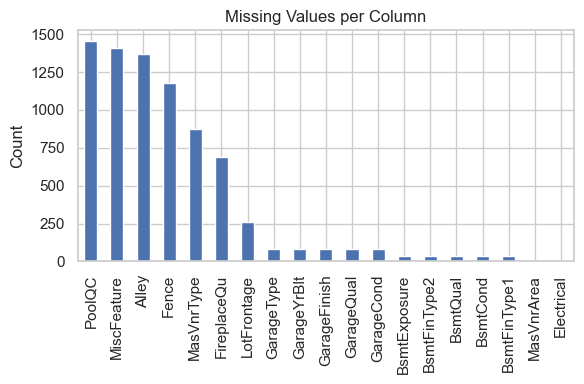

In [80]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6,4))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Target Distribution — `SalePrice`

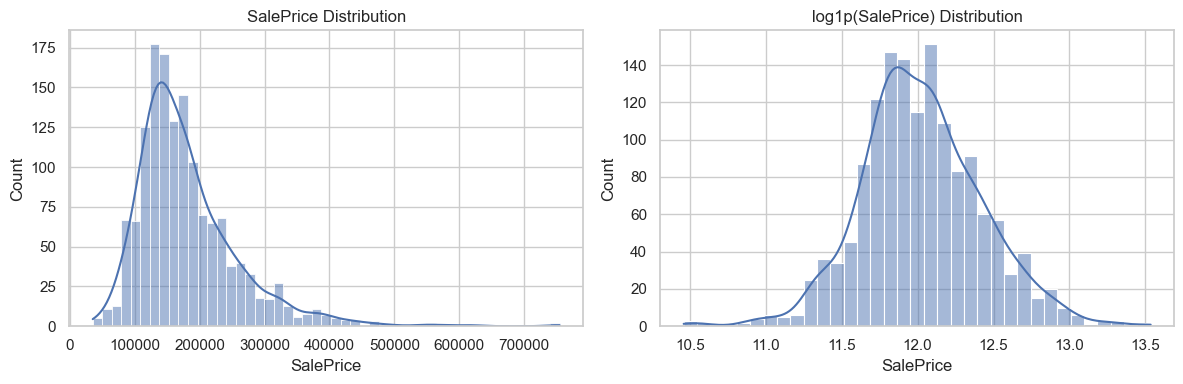

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice) Distribution")
plt.tight_layout()
plt.show()

print(df["SalePrice"].describe())

Feature Correlations

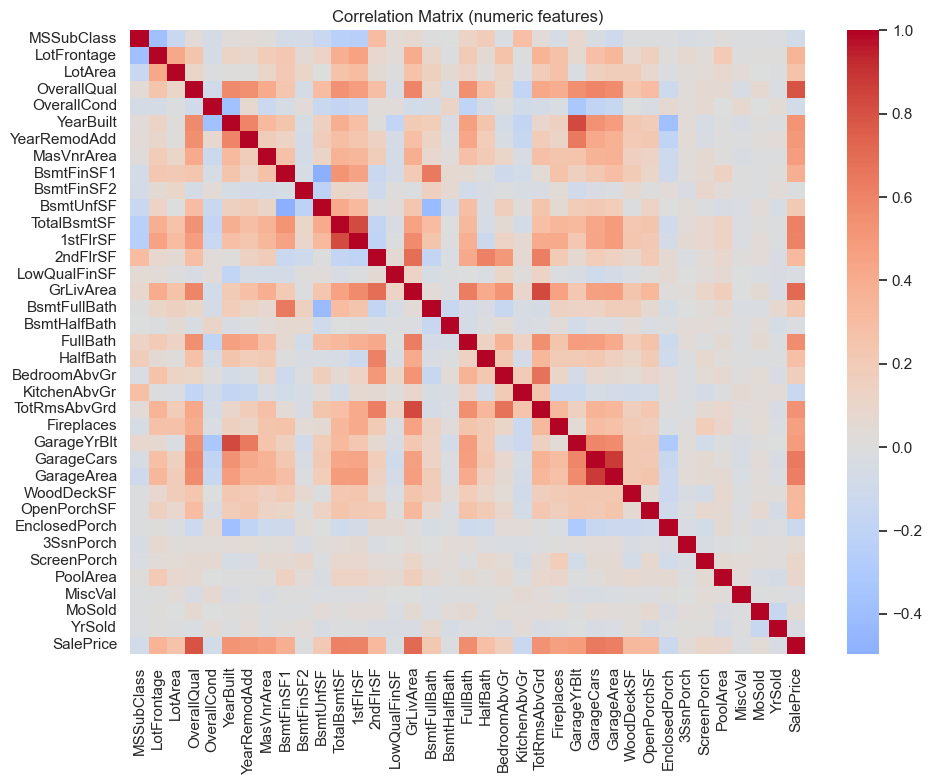

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [82]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["Id"])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

corr["SalePrice"].sort_values(ascending=False)

Key Relationships

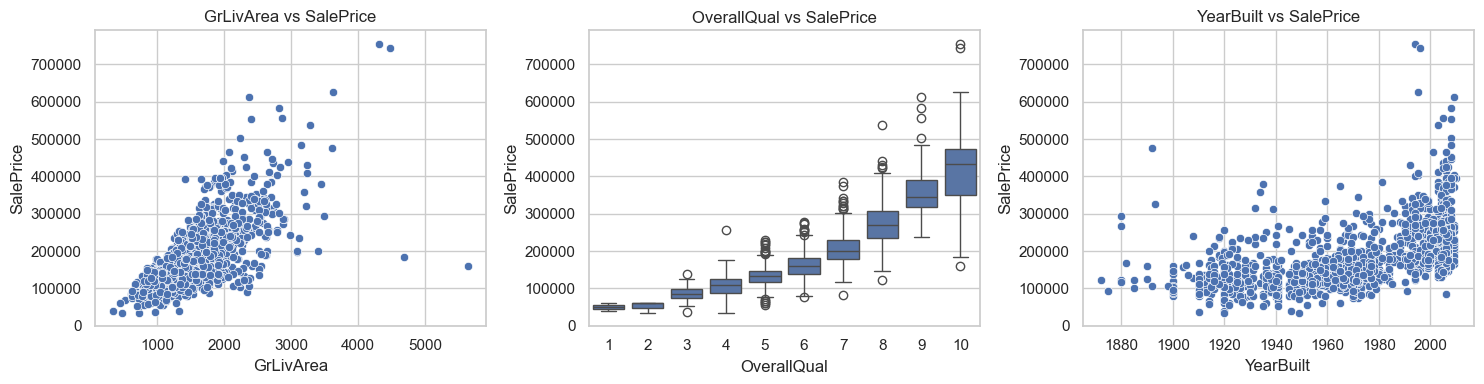

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", ax=axes[0])
axes[0].set_title("GrLivArea vs SalePrice")
sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[1])
axes[1].set_title("OverallQual vs SalePrice")
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice", ax=axes[2])
axes[2].set_title("YearBuilt vs SalePrice")
plt.tight_layout()
plt.show()

Data Pipeline

- Numeric features → median imputation
- Categorical features → most-frequent imputation + one-hot encoding

This is intentionally minimal


In [ ]:
target = "SalePrice"
features = [c for c in df.columns if c not in ["Id", target]]

X = df[features]
y = df[target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
 
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 

In [85]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

Train Baseline Model - A naive baseline `XGBRegressor` with default-ish hyperparameters, no tuning.

In [86]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)
print("Training complete.")

Training complete.


Evaluation

In [87]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(np.clip(preds, 0, None))))

print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"R^2   : {r2:.4f}")
print(f"RMSLE : {rmsle:.4f}  (Actual Competition Metric)")

MAE   : 15,489.71
RMSE  : 24,668.63
R^2   : 0.9207
RMSLE : 0.1323  (Actual Competition Metric)


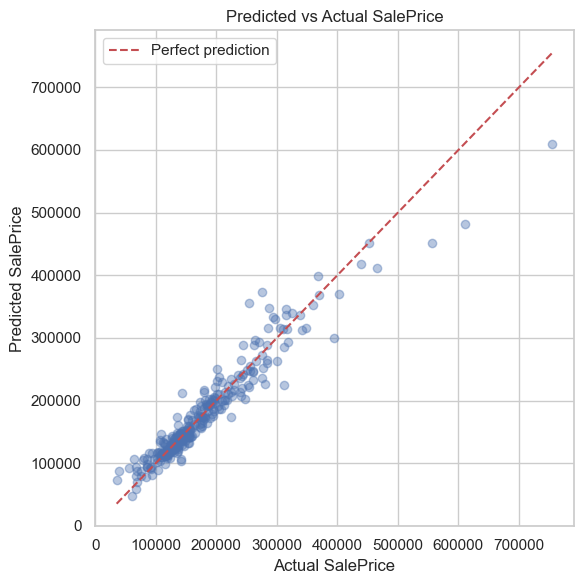

In [88]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

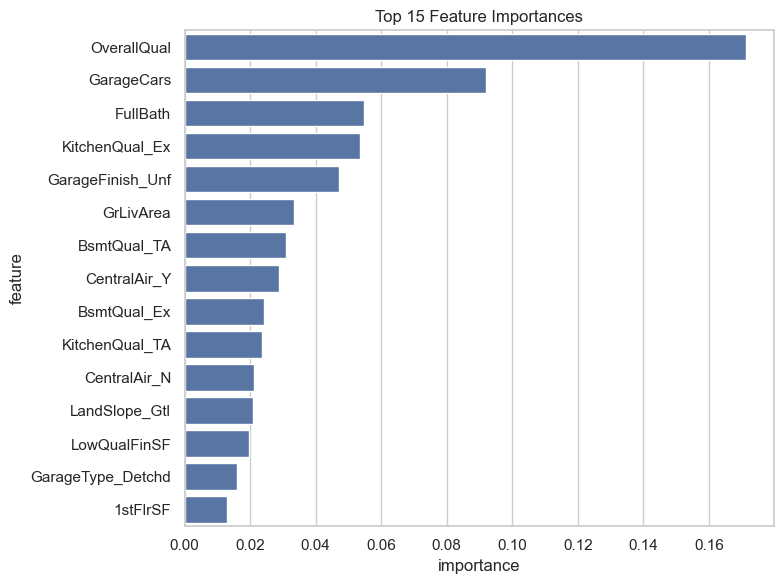

In [89]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_names)

importances = model.named_steps["regressor"].feature_importances_
imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

Model Weights - Saving the full pipeline (preprocessing + model)

In [ ]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(model, "../models/baseline_xgb_pipeline.pkl")
print("Model saved to models/baseline_xgb_pipeline.pkl")

Model saved to models/baseline_xgb_pipeline.pkl


Reload Model & Demo Predictions - loading the saved weights and running inference.

In [91]:
loaded_model = joblib.load("models/baseline_xgb_pipeline.pkl")

sample = X_test.head(5)
sample_preds = loaded_model.predict(sample)

results = pd.DataFrame({
    "Actual SalePrice": y_test.head(5).values,
    "Predicted SalePrice": sample_preds.round(0),
})
results["Abs Error"] = (results["Actual SalePrice"] - results["Predicted SalePrice"]).abs()
results

,Actual SalePrice,Predicted SalePrice,Abs Error
0,154500,143484.0,11016.0
1,325000,339876.0,14876.0
2,115000,110791.0,4209.0
3,159000,156371.0,2629.0
4,315500,336318.0,20818.0


Ideas for go beyond this Prototype
- Hyperparameter tuning (grid/random/Bayesian search) on the XGBoost model
- Feature engineering: total square footage, age at sale, quality×area interactions
- Try alternative baselines (LightGBM, a small NN) and compare
- Handle outliers / skew in `SalePrice` more carefully (e.g. model on `log1p(SalePrice)`)
- Cross-validation instead of a single train/test split for more robust metrics